# Example 2: a thermal XXZ spin chain in the THz regime

A ring of six spin-½ moments with XXZ exchange in a static field is a small many-body system with a real thermal state. At 4 K several magnon-number sectors are populated, so the response is a sum over pathways launched from different sectors. In this notebook you will:

- build the many-body Hamiltonian with QuTiP (`qt.tensor` of single-spin operators);
- cut it into magnon-number sectors, the form the sparse solver expects;
- start from the canonical density matrix at $T=4$ K instead of a pure ground state;
- compute the one-magnon THz response and the third-order rephasing response, including the bimagnon excited-state absorption;
- use the diagonal GMRES preconditioner of the sparse backend to make the 2D scan fast.

Convergence with the magnon cutoff and the dense–sparse comparison are kept out of this notebook; they are in `analysis/example2_truncation_and_backends.ipynb`.

Natural units: $\hbar=1$. Energies in meV, field in tesla, temperature in kelvin, $\mu_B=0.0578838$ meV/T, $k_B=0.0861733$ meV/K.

## 0. Imports

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

from qudpy_fdgf import (
    ExcitationSectorModel,
    FrequencyPathway,
    PropagationInterval,
    SpectroscopyPlotter,
    SpectroscopyProtocol,
    SpectroscopySolver,
    ThermodynamicContext,
    standard_nq_protocol,
)

## 1. Physical model

The Hamiltonian is a periodic XXZ chain in a longitudinal field $B_0$,

$$
H=\sum_j\Big[J_{xy}\big(S^x_jS^x_{j+1}+S^y_jS^y_{j+1}\big)+J_z\,S^z_jS^z_{j+1}\Big]-g\mu_BB_0\sum_jS^z_j ,
$$

measured from the energy of the fully polarized state $|\!\uparrow\cdots\uparrow\rangle$. A **magnon** is one flipped spin, so the magnon number is $N=\sum_j(\tfrac12-S^z_j)$. The Hamiltonian conserves $N$.

The parameters are generic (an easy-axis ferromagnetic chain, not a fit to one compound). With $J_z<0$ two neighbouring magnons attract, which can produce a bound bimagnon state.

The THz magnetic field is uniform over the chain and flips one spin. Its excitation-raising part is

$$M^-=\frac1{\sqrt L}\sum_jS^-_j ,$$

which raises $N$ by one and, being uniform, conserves total momentum.

In [2]:
n_sites = 6
J_xy = -0.30           # meV, transverse exchange
J_z = -0.55            # meV, longitudinal exchange (also the magnon attraction)
g_factor = 2.10
B_0 = 7.1773           # tesla; puts the bright one-magnon state near 1.12 meV
temperature = 4.0      # kelvin
eta = 0.03             # meV, resolvent broadening

MU_B = 0.0578838       # meV / T
K_B = 0.08617333262    # meV / K


def site(op, j):
    """Operator `op` acting on spin j, identity on the others."""
    return qt.tensor([op if k == j else qt.qeye(2) for k in range(n_sites)])


Sx = [site(qt.sigmax() / 2, j) for j in range(n_sites)]
Sy = [site(qt.sigmay() / 2, j) for j in range(n_sites)]
Sz = [site(qt.sigmaz() / 2, j) for j in range(n_sites)]
S_minus = [site(qt.sigmam(), j) for j in range(n_sites)]   # flips |up> to |down>: creates a magnon

H = 0
for j in range(n_sites):
    k = (j + 1) % n_sites       # periodic boundary conditions
    H += J_xy * (Sx[j] * Sx[k] + Sy[j] * Sy[k]) + J_z * Sz[j] * Sz[k] - g_factor * MU_B * B_0 * Sz[j]

all_up = qt.tensor([qt.basis(2, 0)] * n_sites)
H = H - qt.expect(H, all_up)                      # energies relative to the polarized state

N_op = sum(0.5 - Sz[j] for j in range(n_sites))   # magnon number
M_minus = sum(S_minus) / np.sqrt(n_sites)         # uniform THz excitation operator

print(f"Hilbert space dimension: {H.shape[0]} = 2^{n_sites}")

Hilbert space dimension: 64 = 2^6


## 2. Magnon-number sectors

Because $H$ conserves $N$, it is block diagonal. `ExcitationSectorModel` takes the blocks $H_N$ and the rectangular blocks $M_{N+1,N}$ of the raising operator, and never builds the full matrix. We read $N$ off the diagonal of `N_op` and slice with it.

We keep $N\le N_{\max}=4$. A third-order pathway starting in sector $N$ can reach $N+2$, so $N_{\max}=4$ closes every pathway that starts in the thermally relevant sectors $N=0,1,2$ (see the analysis notebook for the truncation error).

In [3]:
max_magnons = 4

magnons = np.rint(N_op.diag().real).astype(int)            # N for each basis state
members = {N: np.flatnonzero(magnons == N) for N in range(max_magnons + 1)}

H_full, M_full = H.full(), M_minus.full()
hamiltonians = {N: H_full[np.ix_(idx, idx)] for N, idx in members.items()}
raising_blocks = {
    (N + 1, N): M_full[np.ix_(members[N + 1], members[N])] for N in range(max_magnons)
}

model = ExcitationSectorModel(
    hamiltonians, raising_blocks, initial_sector=0, boltzmann_constant=K_B
)
print("sector dimensions:", {N: model.dimension(N) for N in model.sectors()})

sector dimensions: {0: 1, 1: 6, 2: 15, 3: 20, 4: 15}


### Check: one-magnon dispersion

In the one-magnon sector the exact energies are $\omega(k)=g\mu_BB_0-J_z+J_{xy}\cos k$. The bright state of a uniform probe is $k=0$, at $g\mu_BB_0-J_z+J_{xy}$. The two-magnon sector contains the (attractive) bimagnon.

In [4]:
k_points = 2 * np.pi * np.arange(n_sites) / n_sites
dispersion = g_factor * MU_B * B_0 - J_z + J_xy * np.cos(k_points)
one_magnon = np.linalg.eigvalsh(hamiltonians[1])
two_magnon = np.linalg.eigvalsh(hamiltonians[2])
bright_energy = g_factor * MU_B * B_0 - J_z + J_xy

print(f"max |E_numerical - E_analytical| (one magnon) = {np.abs(one_magnon - np.sort(dispersion)).max():.1e} meV")
print(f"bright k=0 energy: {bright_energy:.4f} meV")
print(f"two-magnon band: {two_magnon.min():.4f} to {two_magnon.max():.4f} meV "
      f"(binding shift {two_magnon.min() - 2 * bright_energy:+.4f} meV)")
assert np.allclose(one_magnon, np.sort(dispersion), atol=1e-12)

max |E_numerical - E_analytical| (one magnon) = 4.4e-16 meV
bright k=0 energy: 1.1224 meV
two-magnon band: 2.1108 to 3.3155 meV (binding shift -0.1341 meV)


## 3. Thermal initial state

At 4 K the density matrix is $\rho_\beta=e^{-H/k_BT}/Z$, spread over several sectors. We pass `ThermodynamicContext(temperature=4.0)` to the solver, which asks the model for $\rho_\beta$. Here QuTiP gives the exact weights $P_N$ of the full six-site chain for comparison.

In [5]:
rho_beta = (-H / (K_B * temperature)).expm()
rho_beta = rho_beta / rho_beta.tr()
sector_weight = np.array([np.real((rho_beta * qt.Qobj(np.diag(magnons == N).astype(float),
                                                      dims=H.dims)).tr()) for N in range(n_sites + 1)])

for N, weight in enumerate(sector_weight):
    print(f"P(N={N}) = {weight:.6f}" + ("   <- not kept" if N > max_magnons else ""))
print(f"weight beyond N_max = {sector_weight[max_magnons + 1:].sum():.1e}")

P(N=0) = 0.885331
P(N=1) = 0.102734
P(N=2) = 0.010908
P(N=3) = 0.000955
P(N=4) = 0.000069
P(N=5) = 0.000004   <- not kept
P(N=6) = 0.000000   <- not kept
weight beyond N_max = 4.3e-06


At 4 K about 11 % of the population is in $N\ge1$, so a pure-ground-state calculation would miss hot-band contributions. Only $\sim10^{-5}$ lies beyond the retained sectors.

## 4. Solver and diagonal preconditioner

The `sparse_sector` backend never builds the Liouville matrix. It solves each resolvent equation $[(\eta-i\omega)\mathbb 1-\mathcal L]x=b$ iteratively with GMRES (`krylov_tolerance` sets the residual). Here the model is closed (no collapse channels) and given in its eigenbasis, so the generator is diagonal and `preconditioner="diagonal"` is **exact**: every solve converges in one iteration. Without it, the thermal state needs hundreds of iterations per solve and this scan would take hours (iteration counts in `analysis/example2_truncation_and_backends.ipynb`, scaling with chain length in `benchmarks/`). With dissipation the preconditioner remains an approximation.

In [6]:
thermal_context = ThermodynamicContext(temperature=temperature)

solver = SpectroscopySolver(
    backend="sparse_sector", eta=eta, krylov_tolerance=1e-11, preconditioner="diagonal"
)
solver.feed_model(model, context=thermal_context)

# Same model, pure ground state, for comparison
solver_pure = SpectroscopySolver(
    backend="sparse_sector", eta=eta, krylov_tolerance=1e-11, preconditioner="diagonal"
)
solver_pure.feed_model(model)

print(solver.summary()["backend"], solver.summary()["sector_dimensions"])

sparse_sector {0: 1, 1: 6, 2: 15, 3: 20, 4: 15}


## 5. Linear THz response

One interaction `Ku` creates the coherence $|1\text{ magnon}\rangle\langle G|$. A uniform probe selects the $k=0$ magnon, so the pure-ground-state response peaks at the bright energy. At 4 K the thermally populated sectors add momentum-compatible hot bands ($N\to N+1$ transitions).

A protocol with one frequency interval and a single pathway is enough.

pure-state peak at 1.117 meV (expected 1.122 meV)


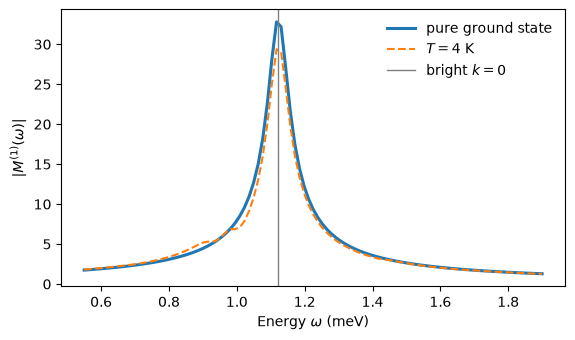

In [7]:
linear_pathway = FrequencyPathway(name="linear", interactions=("Ku",), component="linear")
linear_protocol = SpectroscopyProtocol(
    intervals=(PropagationInterval("omega", "frequency", coherence_order=1),), name="linear"
)

omega = np.linspace(0.55, 1.90, 101)


def linear_response(sol):
    return np.array(
        [sol.calc_pathway(linear_pathway, linear_protocol, {"omega": w}).value for w in omega]
    )


linear_pure = linear_response(solver_pure)
linear_thermal = linear_response(solver)

peak = omega[np.argmax(np.abs(linear_pure))]
print(f"pure-state peak at {peak:.3f} meV (expected {bright_energy:.3f} meV)")
assert abs(peak - bright_energy) < 2 * (omega[1] - omega[0])

linear_figure, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(omega, np.abs(linear_pure), lw=2.2, label="pure ground state")
ax.plot(omega, np.abs(linear_thermal), "--", label=f"$T={temperature:.0f}$ K")
ax.axvline(bright_energy, color="0.5", lw=1, label=r"bright $k=0$")
ax.set_xlabel(r"Energy $\omega$ (meV)")
ax.set_ylabel(r"$|M^{(1)}(\omega)|$")
ax.legend(frameon=False)
plt.show()

## 6. Third-order rephasing response

The three rephasing pathways all follow the coherence orders $q=(-1,0,+1)$:

$$R_{\rm GSB}=(B_u,B_d,K_u),\qquad R_{\rm SE}=(B_u,K_u,B_d),\qquad R_{\rm ESA}=(B_u,K_u,K_u).$$

$R_{\rm ESA}$ goes to the two-magnon sector and leaves a $|2\text{ mag}\rangle\langle1\text{ mag}|$ coherence, which is where the bimagnon appears. At 4 K the same labels act on every populated diagonal block of $\rho_\beta$, so GSB, SE and ESA name *topologies*, not only processes starting in the ground state.

The waiting time is $t_2=0$. The grid is $60\times60$ points, $\Delta\omega\approx0.017$ meV.

In [8]:
pathways = (
    FrequencyPathway(name="GSB", interactions=("Bu", "Bd", "Ku"), component="rephasing"),
    FrequencyPathway(name="SE", interactions=("Bu", "Ku", "Bd"), component="rephasing"),
    FrequencyPathway(name="ESA", interactions=("Bu", "Ku", "Ku"), component="rephasing"),
)
protocol = standard_nq_protocol(
    order=1, nq_interval=1, detection_interval=3, n_interactions=3,
    nq_axis="omega_1q", detection_axis="omega_emit",
)

omega_1q = np.linspace(-1.55, -0.55, 60)
omega_emit = np.linspace(0.55, 1.55, 60)

start = time.perf_counter()
result = solver.generate_spectrum(
    protocol,
    axes={"omega_1q": omega_1q, "omega_emit": omega_emit},
    fixed_coordinates={"t2": 0.0},
    pathways=pathways,
)
print(f"2D scan: {time.perf_counter() - start:.0f} s")

gsb, se, esa = (result.pathways[name] for name in ("GSB", "SE", "ESA"))
rephasing = result.components["rephasing"]

2D scan: 139 s


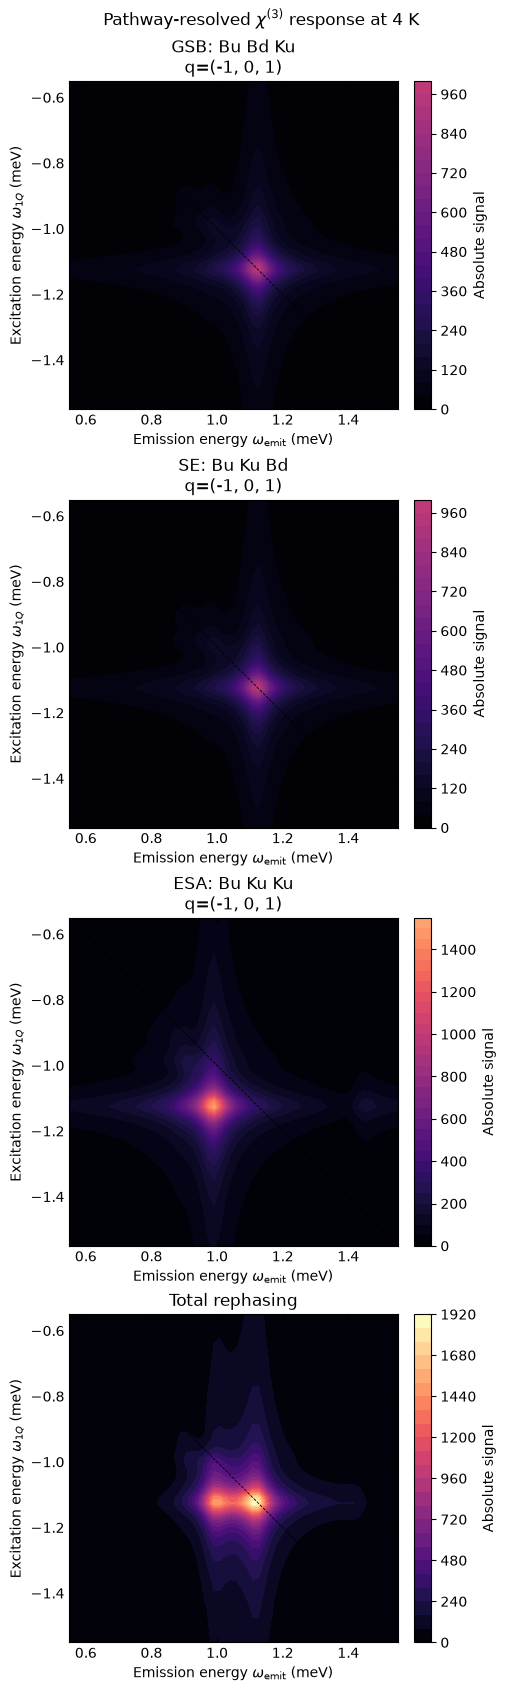

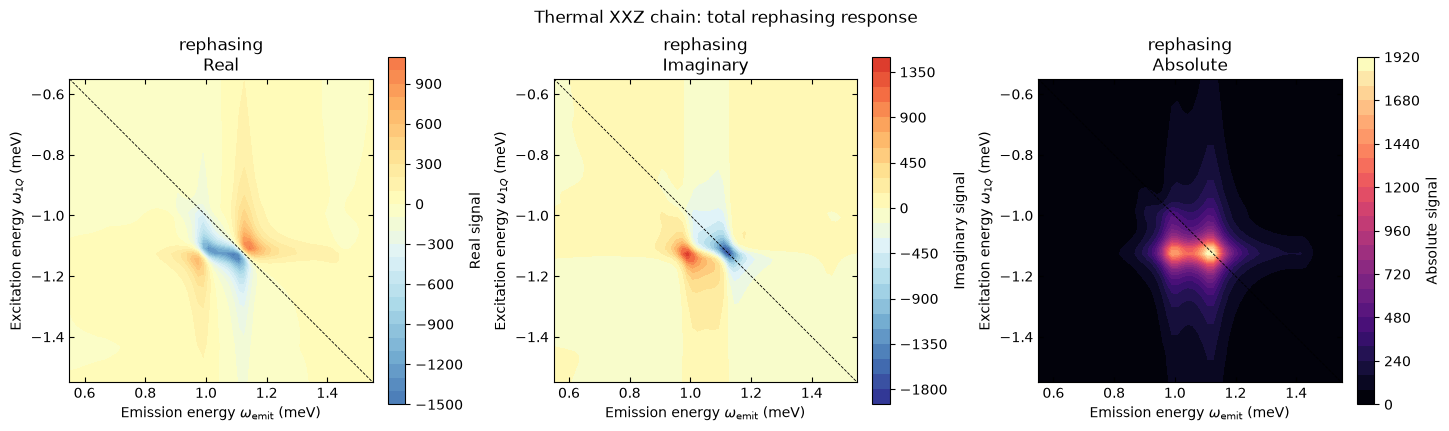

In [9]:
plotter = SpectroscopyPlotter(detection_phase=0.0)
axis_labels = (
    r"Emission energy $\omega_{\mathrm{emit}}$ (meV)",
    r"Excitation energy $\omega_{1Q}$ (meV)",
)

pathway_figure = plotter.plot_spectrum_result(
    result,
    params={
        "source": "pathways", "names": ["GSB", "SE", "ESA"], "view": "abs",
        "normalization": "global", "labels": axis_labels, "diagonals": "auto",
        "title": r"Pathway-resolved $\chi^{(3)}$ response at 4 K",
        "style": {"abs_cmap": "magma", "levels": 30, "contour_lines": False},
    },
)
total_figure = plotter.plot_spectrum_result(
    result,
    params={
        "source": "components", "names": ["rephasing"], "view": "all",
        "normalization": "row", "labels": axis_labels, "diagonals": "auto",
        "title": r"Thermal XXZ chain: total rephasing response",
        "style": {"cmap": "RdYlBu_r", "abs_cmap": "magma", "levels": 30, "contour_lines": False},
    },
)

GSB and SE sit on the bright one-magnon resonance, $(\omega_{1Q},\omega_{\rm emit})\approx(-1.12,+1.12)$ meV. ESA starts from the same excitation energy but is emitted at $E_{\rm bimagnon}-E_{\rm bright}\approx0.99$ meV, below the diagonal by the bimagnon binding shift ($-0.134$ meV, Section 2). The total map therefore shows two peaks along $\omega_{1Q}\approx-1.12$ meV. Their splitting is the signature of the interaction $J_z$.

## 7. Verification

Three checks that do not depend on how the map looks:
- the total is the sum of its pathways;
- the strongest feature lies at the bright magnon resonance;
- the ESA peak is emitted at $E_{\rm bimagnon}-E_{\rm bright}$, which requires the two-magnon sector.

In [10]:
sum_residual = np.max(np.abs(rephasing - (gsb + se + esa)))
i, j = np.unravel_index(np.argmax(np.abs(rephasing)), rephasing.shape)
print(f"|total - (GSB + SE + ESA)| = {sum_residual:.1e}")
print(f"strongest feature: ({omega_1q[i]:.3f}, {omega_emit[j]:.3f}) meV; expected ({-bright_energy:.3f}, {bright_energy:.3f}) meV")
esa_i, esa_j = np.unravel_index(np.argmax(np.abs(esa)), esa.shape)
bimagnon_emission = two_magnon.min() - bright_energy
print(f"ESA peak: ({omega_1q[esa_i]:.3f}, {omega_emit[esa_j]:.3f}) meV; expected emission {bimagnon_emission:.3f} meV")

assert sum_residual < 1e-10
assert abs(omega_1q[i] + bright_energy) < 0.05 and abs(omega_emit[j] - bright_energy) < 0.05
assert abs(omega_emit[esa_j] - bimagnon_emission) < 0.05

|total - (GSB + SE + ESA)| = 0.0e+00
strongest feature: (-1.126, 1.109) meV; expected (-1.122, 1.122) meV
ESA peak: (-1.126, 0.991) meV; expected emission 0.988 meV


## 8. Save the results

The analysis notebook `validation/analysis/example2_analysis.ipynb` starts from these files. The `.npz` contains the parameters, the energies used in the checks, the thermal weights, the linear response and the three pathway maps.

In [11]:
from pathlib import Path

results = Path("../validation/results")
(results / "data").mkdir(parents=True, exist_ok=True)
(results / "figure").mkdir(parents=True, exist_ok=True)

np.savez(
    results / "data" / "example2.npz",
    n_sites=n_sites, max_magnons=max_magnons, temperature=temperature, eta=eta,
    J_xy=J_xy, J_z=J_z, g_factor=g_factor, B_0=B_0,
    bright_energy=bright_energy, one_magnon=one_magnon, two_magnon=two_magnon,
    sector_weight=sector_weight,
    omega=omega, linear_pure=linear_pure, linear_thermal=linear_thermal,
    omega_1q=omega_1q, omega_emit=omega_emit, gsb=gsb, se=se, esa=esa, rephasing=rephasing,
)
linear_figure.savefig(results / "figure" / "example2_linear_response.pdf", bbox_inches="tight")
pathway_figure.figure.savefig(results / "figure" / "example2_pathways.pdf", bbox_inches="tight")
total_figure.figure.savefig(results / "figure" / "example2_rephasing.pdf", bbox_inches="tight")
print("saved", results / "data" / "example2.npz")

saved ..\validation\results\data\example2.npz


## Summary

- The many-body Hamiltonian is built with QuTiP from single-spin operators, then cut into magnon-number sectors.
- `ThermodynamicContext` gives a canonical initial state spread over several sectors; the response is the sum over all populated blocks.
- The uniform THz probe selects the $k=0$ magnon; thermal population adds hot bands, and the bimagnon shows up as the ESA peak, shifted by its binding energy.
- `preconditioner="diagonal"` makes the sparse GMRES solves exact for this closed model.

Limits: magnon-number conservation is exact, the linewidth is phenomenological ($\eta$), and there is no thermal relaxation or detailed balance in the dynamics. Parameters are illustrative.